In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from scipy.optimize import curve_fit
import pickle

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern"
})

In [3]:
hank_blue = (0, 114/256, 178/256)
hank_orange = (213/256, 94/256, 0)

# exact answer

In [4]:
ferm_num_exact_no_noise_no_knit=np.load('data/ferm_num_exact_no_noise_no_knit.npy')
bs_error_exact_no_noise_no_knit=np.load('data/bs_error_exact_no_noise_no_knit.npy')

In [5]:
# plt.scatter(trotter_steps[:8], ferm_num_exact_no_noise_no_knit[:8], color='black')
# plt.plot(trotter_steps[:8], [fit_func(i, *ans) for i in trotter_steps][:8], color='black')
# plt.show()

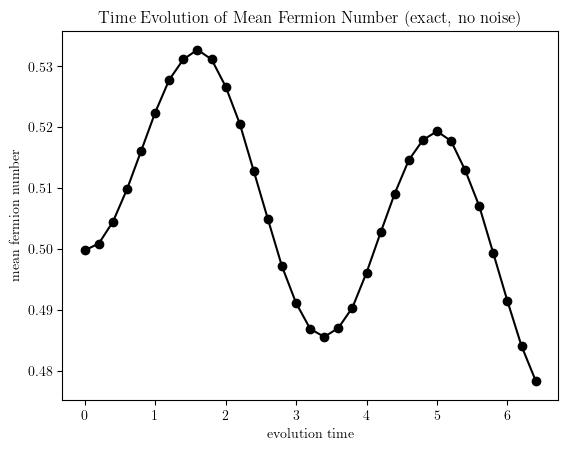

In [6]:
trotter_steps = [item*0.2 for item in range(len(ferm_num_exact_no_noise_no_knit))]
plt.scatter(trotter_steps, ferm_num_exact_no_noise_no_knit, color='black')
plt.errorbar(trotter_steps, ferm_num_exact_no_noise_no_knit, bs_error_exact_no_noise_no_knit, alpha=0.2, ls='none', color='black')
plt.plot(trotter_steps, ferm_num_exact_no_noise_no_knit, color='black')
plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('Time Evolution of Mean Fermion Number (exact, no noise)')
plt.show()

# noisy, not knitted

In [7]:
with open('data/noisy_no_knit_trotter_evolution.pkl', 'rb') as file:
    noisy_no_knit_trotter_evolution = pickle.load(file)
with open('data/noisy_knitted_trotter_evolution.pkl', 'rb') as file:
    noisy_knitted_trotter_evolution = pickle.load(file)

trotter_steps=np.linspace(0, 1.6, 9)

ferm_num_exact_no_noise_no_knit=np.load('data/ferm_num_exact_no_noise_no_knit.npy')[:9]
bs_error_exact_no_noise_no_knit=np.load('data/bs_error_exact_no_noise_no_knit.npy')[:9]

no_knit_noisy_resampled_fermion_number=np.load('data/no_knit_noisy_resampled_fermion_number.npy')
no_knit_noisy_resampled_bootstrap_error=np.load('data/no_knit_noisy_resampled_bootstrap_error.npy')

knitted_noisy_resampled_fermion_number=np.load('data/knitted_noisy_resampled_fermion_number.npy')
knitted_noisy_resampled_bootstrap_error=np.load('data/knitted_noisy_resampled_bootstrap_error.npy')

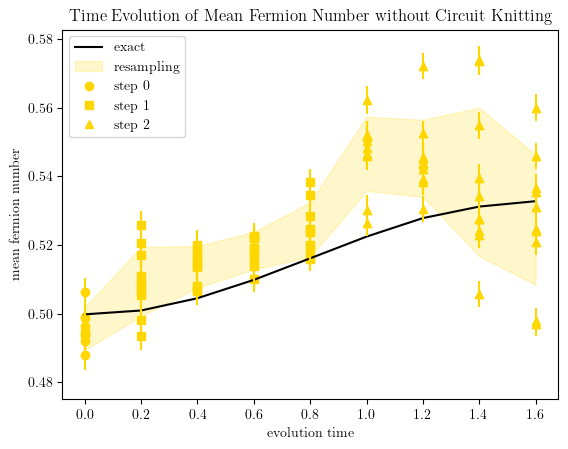

In [8]:
for item in noisy_knitted_trotter_evolution:
    points = noisy_knitted_trotter_evolution[item]['fermion_number']
    error = noisy_knitted_trotter_evolution[item]['bootstrap_error']
    plt.scatter(trotter_steps, points, color='white', alpha=0)
    plt.errorbar(trotter_steps, points, error, ls='none', color='white', alpha=0)

plt.fill_between(trotter_steps, knitted_noisy_resampled_fermion_number+knitted_noisy_resampled_bootstrap_error,\
                 knitted_noisy_resampled_fermion_number-knitted_noisy_resampled_bootstrap_error, color='white', alpha=0)

plt.plot(trotter_steps, ferm_num_exact_no_noise_no_knit, color='black', label='exact')

for item in noisy_no_knit_trotter_evolution:
    points = noisy_no_knit_trotter_evolution[item]['fermion_number']
    error = noisy_no_knit_trotter_evolution[item]['bootstrap_error']
    for i, evolution_time in enumerate(trotter_steps):
        if evolution_time == 0.: marker = 'o'
        elif evolution_time in np.linspace(0.2, 0.8, 4):marker = 's'
        else: marker = '^'
        plt.scatter(evolution_time, points[i], color='gold', marker=marker)
    plt.errorbar(trotter_steps, points, error, ls='none', color='gold')

plt.fill_between(trotter_steps, no_knit_noisy_resampled_fermion_number+no_knit_noisy_resampled_bootstrap_error,\
                 no_knit_noisy_resampled_fermion_number-no_knit_noisy_resampled_bootstrap_error, color='gold', alpha=0.2, label='resampling')

handles, labels = plt.gca().get_legend_handles_labels()

step0 = Line2D([0], [0], label='step 0', marker='o', color='gold', linestyle='')
step1 = Line2D([0], [0], label='step 1', marker='s', color='gold', linestyle='')
step2 = Line2D([0], [0], label='step 2', marker='^', color='gold', linestyle='')

handles.extend([step0, step1, step2])

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('Time Evolution of Mean Fermion Number without Circuit Knitting')
plt.legend(loc='upper left', handles=handles)
plt.savefig('figures/fermion_number_no_knitting.pdf')
plt.show()

# noisy, knitted

In [9]:
trotter_steps=np.linspace(0, 1.6, 9)

ferm_num_exact_no_noise_no_knit=np.load('data/ferm_num_exact_no_noise_no_knit.npy')
bs_error_exact_no_noise_no_knit=np.load('data/bs_error_exact_no_noise_no_knit.npy')

ferm_num_exact_no_noise_no_knit=ferm_num_exact_no_noise_no_knit[:len(trotter_steps)]
bs_error_exact_no_noise_no_knit=bs_error_exact_no_noise_no_knit[:len(trotter_steps)]

In [10]:
knitted_noisy_resampled_fermion_number=np.load('data/knitted_noisy_resampled_fermion_number.npy')
knitted_noisy_resampled_bootstrap_error=np.load('data/knitted_noisy_resampled_bootstrap_error.npy')

In [11]:
with open('data/noisy_knitted_trotter_evolution.pkl', 'rb') as file:
    noisy_knitted_trotter_evolution = pickle.load(file)

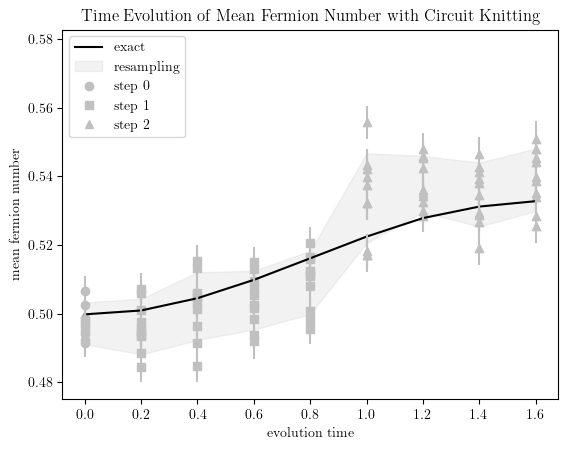

In [12]:
for item in noisy_no_knit_trotter_evolution:
    points = noisy_no_knit_trotter_evolution[item]['fermion_number']
    error = noisy_no_knit_trotter_evolution[item]['bootstrap_error']
    plt.scatter(trotter_steps, points, color='white', alpha=0)
    plt.errorbar(trotter_steps, points, error, ls='none', color='white', alpha=0)

plt.fill_between(trotter_steps, no_knit_noisy_resampled_fermion_number+no_knit_noisy_resampled_bootstrap_error,\
                 no_knit_noisy_resampled_fermion_number-no_knit_noisy_resampled_bootstrap_error, color='white', alpha=0)

plt.plot(trotter_steps, ferm_num_exact_no_noise_no_knit, color='black', label='exact')

for item in noisy_knitted_trotter_evolution:
    points = noisy_knitted_trotter_evolution[item]['fermion_number']
    error = noisy_knitted_trotter_evolution[item]['bootstrap_error']
    for i, evolution_time in enumerate(trotter_steps):
        if evolution_time == 0.: marker = 'o'
        elif evolution_time in np.linspace(0.2, 0.8, 4): marker = 's'
        else: marker = '^'
        plt.scatter(evolution_time, points[i], color='silver', marker=marker)
    plt.errorbar(trotter_steps, points, error, ls='none', color='silver')

plt.fill_between(trotter_steps, knitted_noisy_resampled_fermion_number+knitted_noisy_resampled_bootstrap_error,\
                 knitted_noisy_resampled_fermion_number-knitted_noisy_resampled_bootstrap_error, color='silver', alpha=0.2, label='resampling')

handles, labels = plt.gca().get_legend_handles_labels()

step0 = Line2D([0], [0], label='step 0', marker='o', color='silver', linestyle='')
step1 = Line2D([0], [0], label='step 1', marker='s', color='silver', linestyle='')
step2 = Line2D([0], [0], label='step 2', marker='^', color='silver', linestyle='')

handles.extend([step0, step1, step2])

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('Time Evolution of Mean Fermion Number with Circuit Knitting')
plt.legend(loc='upper left', handles=handles)
plt.savefig('figures/fermion_number_with_knitting.pdf')
plt.show()

# All

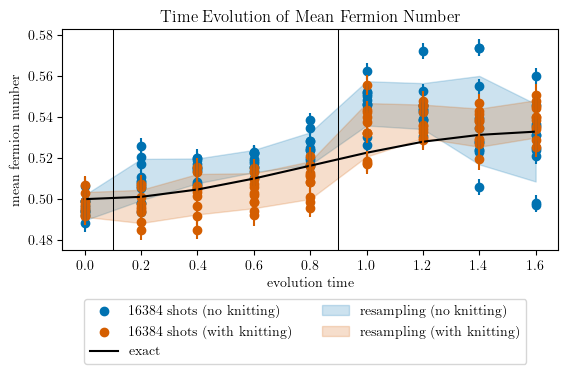

In [13]:
fig, ax = plt.subplots()

plt.scatter(trotter_steps, noisy_no_knit_trotter_evolution[474456]['fermion_number'], color=hank_blue, label='16384 shots (no knitting)')
plt.scatter(trotter_steps, noisy_knitted_trotter_evolution[1765013122]['fermion_number'], color=hank_orange, label='16384 shots (with knitting)')
plt.plot(trotter_steps, ferm_num_exact_no_noise_no_knit, color='black', label='exact')
plt.fill_between(trotter_steps, no_knit_noisy_resampled_fermion_number+no_knit_noisy_resampled_bootstrap_error,\
                  no_knit_noisy_resampled_fermion_number-no_knit_noisy_resampled_bootstrap_error, color=hank_blue, alpha=0.2, label='resampling (no knitting)')
plt.fill_between(trotter_steps, knitted_noisy_resampled_fermion_number+knitted_noisy_resampled_bootstrap_error,\
                 knitted_noisy_resampled_fermion_number-knitted_noisy_resampled_bootstrap_error, color=hank_orange, alpha=0.2, label='resampling (with knitting)')



for item in noisy_no_knit_trotter_evolution:
    points = noisy_no_knit_trotter_evolution[item]['fermion_number']
    error = noisy_no_knit_trotter_evolution[item]['bootstrap_error']
    plt.scatter(trotter_steps, points, color=hank_blue)
    plt.errorbar(trotter_steps, points, error, ls='none', color=hank_blue)



for item in noisy_knitted_trotter_evolution:
    points = noisy_knitted_trotter_evolution[item]['fermion_number']
    error = noisy_knitted_trotter_evolution[item]['bootstrap_error']
    plt.scatter(trotter_steps, points, color=hank_orange)
    plt.errorbar(trotter_steps, points, error, ls='none', color=hank_orange)

# handles, labels = plt.gca().get_legend_handles_labels()

# step0_no_knit = Line2D([0], [0], label='step 0', marker='o', color=hank_blue, linestyle='')
# step1_no_knit = Line2D([0], [0], label='step 1', marker='s', color=hank_blue, linestyle='')
# step2_no_knit = Line2D([0], [0], label='step 2', marker='^', color=hank_blue, linestyle='')
# step0_knitted = Line2D([0], [0], label='step 0', marker='o', color=hank_orange, linestyle='')
# step1_knitted = Line2D([0], [0], label='step 1', marker='s', color=hank_orange, linestyle='')
# step2_knitted = Line2D([0], [0], label='step 2', marker='^', color=hank_orange, linestyle='')

# handles.extend([step0_knitted, step1_knitted, step2_knitted, step0_no_knit, step1_no_knit, step2_no_knit])

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('Time Evolution of Mean Fermion Number')
# plt.legend(loc='upper left', handles=handles)
plt.legend(loc='lower right', ncol=2, bbox_to_anchor=(0.95, -0.55))
ratio = 4/9
x_left, x_right = ax.get_xlim()
y_low, y_high = ax.get_ylim()
ax.set_aspect(abs((x_right-x_left)/(y_low-y_high))*ratio)

plt.autoscale(False)
plt.plot([0.1, 0.1], [0.45, 0.6], color='black', linewidth=0.75)
plt.plot([0.9, 0.9], [0.45, 0.6], color='black', linewidth=0.75)


plt.savefig('figures/fermion_number_with_vs_without_knitting_scatter.pdf', bbox_inches='tight')
plt.show()

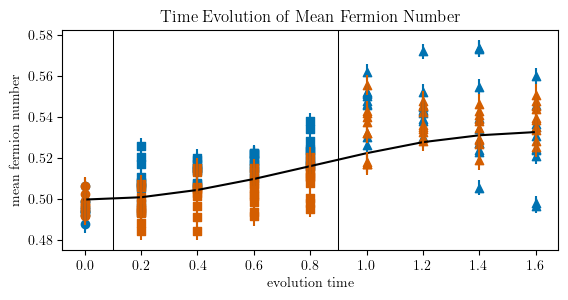

In [43]:
fig, ax = plt.subplots()

plt.plot(trotter_steps, ferm_num_exact_no_noise_no_knit, color='black', label='exact')

for item in noisy_no_knit_trotter_evolution:
    points = noisy_no_knit_trotter_evolution[item]['fermion_number']
    error = noisy_no_knit_trotter_evolution[item]['bootstrap_error']
    for i, evolution_time in enumerate(trotter_steps):
        if evolution_time == 0.: marker = 'o'
        elif evolution_time in np.linspace(0.2, 0.8, 4):marker = 's'
        else: marker = '^'
        plt.scatter(evolution_time, points[i], color=hank_blue, marker=marker)
    plt.errorbar(trotter_steps, points, error, ls='none', color=hank_blue)
# plt.fill_between(trotter_steps, no_knit_noisy_resampled_fermion_number+no_knit_noisy_resampled_bootstrap_error,\
#                  no_knit_noisy_resampled_fermion_number-no_knit_noisy_resampled_bootstrap_error, color=hank_blue, alpha=0.2, label='resampling')

for item in noisy_knitted_trotter_evolution:
    points = noisy_knitted_trotter_evolution[item]['fermion_number']
    error = noisy_knitted_trotter_evolution[item]['bootstrap_error']
    for i, evolution_time in enumerate(trotter_steps):
        if evolution_time == 0.: marker = 'o'
        elif evolution_time in np.linspace(0.2, 0.8, 4): marker = 's'
        else: marker = '^'
        plt.scatter(evolution_time, points[i], color=hank_orange, marker=marker)
    plt.errorbar(trotter_steps, points, error, ls='none', color=hank_orange)
# plt.fill_between(trotter_steps, knitted_noisy_resampled_fermion_number+knitted_noisy_resampled_bootstrap_error,\
#                  knitted_noisy_resampled_fermion_number-knitted_noisy_resampled_bootstrap_error, color=hank_orange, alpha=0.2, label='resampling')

handles, labels = plt.gca().get_legend_handles_labels()

step0_no_knit = Line2D([0], [0], label='step 0', marker='o', color=hank_blue, linestyle='')
step1_no_knit = Line2D([0], [0], label='step 1', marker='s', color=hank_blue, linestyle='')
step2_no_knit = Line2D([0], [0], label='step 2', marker='^', color=hank_blue, linestyle='')
step0_knitted = Line2D([0], [0], label='step 0', marker='o', color=hank_orange, linestyle='')
step1_knitted = Line2D([0], [0], label='step 1', marker='s', color=hank_orange, linestyle='')
step2_knitted = Line2D([0], [0], label='step 2', marker='^', color=hank_orange, linestyle='')

handles.extend([step0_knitted, step1_knitted, step2_knitted, step0_no_knit, step1_no_knit, step2_no_knit])

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('Time Evolution of Mean Fermion Number')
#plt.legend(loc='upper left', handles=handles)

ratio = 4/9
x_left, x_right = ax.get_xlim()
y_low, y_high = ax.get_ylim()
ax.set_aspect(abs((x_right-x_left)/(y_low-y_high))*ratio)

plt.autoscale(False)
plt.plot([0.1, 0.1], [0.45, 0.6], color='black', linewidth=0.75)
plt.plot([0.9, 0.9], [0.45, 0.6], color='black', linewidth=0.75)


plt.savefig('figures/fermion_number_with_vs_without_knitting_scatter.pdf')
plt.show()

In [15]:
def fit_func(x, A, B, C, D, E):
    return A*np.exp(-B*x) * np.cos(C*x) + D + E*x

In [49]:
params_noisy_knitted, _ = curve_fit(fit_func, trotter_steps, knitted_noisy_resampled_fermion_number, sigma=knitted_noisy_resampled_bootstrap_error)

In [28]:
params_noisy_no_knitt, _ = curve_fit(fit_func, trotter_steps, no_knit_noisy_resampled_fermion_number, sigma=no_knit_noisy_resampled_bootstrap_error, maxfev=120000)

In [33]:
params_noisy_knitted

array([-0.01307215, -0.70839623,  2.35307894,  0.51045086, -0.00380759])

In [29]:
params_noisy_no_knitt

array([-1.01506791e+03,  4.62751648e-02, -4.75206014e-02,  1.01556524e+03,
       -4.69559134e+01])

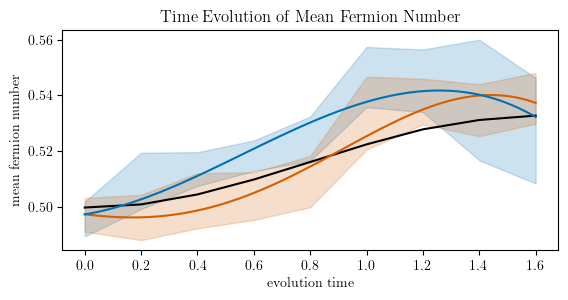

In [48]:
fig, ax = plt.subplots()

plt.plot(trotter_steps, ferm_num_exact_no_noise_no_knit, color='black', label='exact')

plt.fill_between(trotter_steps, no_knit_noisy_resampled_fermion_number+no_knit_noisy_resampled_bootstrap_error,\
                 no_knit_noisy_resampled_fermion_number-no_knit_noisy_resampled_bootstrap_error, color=hank_blue, alpha=0.2, label='resampling')
plt.plot(np.linspace(0, 1.6, 100), [fit_func(i, *params_noisy_knitted) for i in np.linspace(0, 1.6, 100)], color=hank_orange)

plt.fill_between(trotter_steps, knitted_noisy_resampled_fermion_number+knitted_noisy_resampled_bootstrap_error,\
                 knitted_noisy_resampled_fermion_number-knitted_noisy_resampled_bootstrap_error, color=hank_orange, alpha=0.2, label='resampling')
plt.plot(np.linspace(0, 1.6, 100), [fit_func(i, *params_noisy_no_knitt) for i in np.linspace(0, 1.6, 100)], color=hank_blue)

handles, labels = plt.gca().get_legend_handles_labels()

step0_no_knit = Line2D([0], [0], label='step 0', marker='o', color=hank_blue, linestyle='')
step1_no_knit = Line2D([0], [0], label='step 1', marker='s', color=hank_blue, linestyle='')
step2_no_knit = Line2D([0], [0], label='step 2', marker='^', color=hank_blue, linestyle='')
step0_knitted = Line2D([0], [0], label='step 0', marker='o', color=hank_orange, linestyle='')
step1_knitted = Line2D([0], [0], label='step 1', marker='s', color=hank_orange, linestyle='')
step2_knitted = Line2D([0], [0], label='step 2', marker='^', color=hank_orange, linestyle='')

handles.extend([step0_knitted, step1_knitted, step2_knitted, step0_no_knit, step1_no_knit, step2_no_knit])

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('Time Evolution of Mean Fermion Number')
#plt.legend(loc='upper left', handles=handles)

ratio = 4/9
x_left, x_right = ax.get_xlim()
y_low, y_high = ax.get_ylim()
ax.set_aspect(abs((x_right-x_left)/(y_low-y_high))*ratio)

plt.autoscale(False)


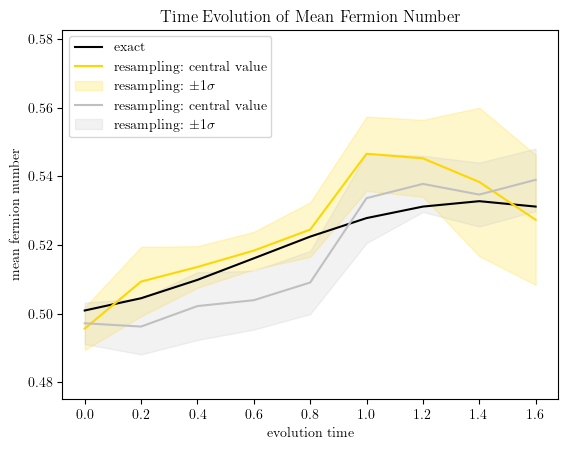

In [13]:
for item in noisy_no_knit_trotter_evolution:
    points = noisy_no_knit_trotter_evolution[item]['fermion_number']
    error = noisy_no_knit_trotter_evolution[item]['bootstrap_error']
    plt.scatter(trotter_steps, points, color='white', alpha=0)
    plt.errorbar(trotter_steps, points, error, ls='none', color='white', alpha=0)

plt.fill_between(trotter_steps, no_knit_noisy_resampled_fermion_number+no_knit_noisy_resampled_bootstrap_error,\
                 no_knit_noisy_resampled_fermion_number-no_knit_noisy_resampled_bootstrap_error, color='white', alpha=0)

for item in noisy_knitted_trotter_evolution:
    points = noisy_knitted_trotter_evolution[item]['fermion_number']
    error = noisy_knitted_trotter_evolution[item]['bootstrap_error']
    plt.scatter(trotter_steps, points, color='white', alpha=0)
    plt.errorbar(trotter_steps, points, error, ls='none', color='white', alpha=0)

plt.fill_between(trotter_steps, knitted_noisy_resampled_fermion_number+knitted_noisy_resampled_bootstrap_error,\
                 knitted_noisy_resampled_fermion_number-knitted_noisy_resampled_bootstrap_error, color='white', alpha=0)

plt.plot(trotter_steps, ferm_num_exact_no_noise_no_knit, color='black', label='exact')

plt.plot(trotter_steps, no_knit_noisy_resampled_fermion_number, color='gold', label='resampling: central value')
plt.fill_between(trotter_steps, no_knit_noisy_resampled_fermion_number+no_knit_noisy_resampled_bootstrap_error,\
                 no_knit_noisy_resampled_fermion_number-no_knit_noisy_resampled_bootstrap_error, color='gold', alpha=0.2, label='resampling: $\\pm 1 \\sigma$')

plt.plot(trotter_steps, knitted_noisy_resampled_fermion_number, color='silver', label='resampling: central value')
plt.fill_between(trotter_steps, knitted_noisy_resampled_fermion_number+knitted_noisy_resampled_bootstrap_error,\
                 knitted_noisy_resampled_fermion_number-knitted_noisy_resampled_bootstrap_error, color='silver', alpha=0.2, label='resampling: $\\pm 1 \\sigma$')


plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('Time Evolution of Mean Fermion Number')
plt.legend(loc='upper left')
plt.savefig('figures/fermion_number_with_vs_without_knitting_central_value.pdf')
plt.show()

In [30]:
ferm_num_trotter_evol_noisy_no_knit = []
with open('data/ferm_num_trotter_evol_noisy_no_knit.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        ferm_num_trotter_evol_noisy_no_knit.append(float(val))

bs_error_trotter_evol_noisy_no_knit = []
with open('data/bs_error_trotter_evol_noisy_no_knit.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        bs_error_trotter_evol_noisy_no_knit.append(float(val))

In [31]:
ferm_num_trotter_evol_noisy_no_knit_seed1763593036 = []
with open('data/ferm_num_trotter_evol_noisy_no_knit_seed1763593036.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        ferm_num_trotter_evol_noisy_no_knit_seed1763593036.append(float(val))

bs_error_trotter_evol_noisy_no_knit_seed1763593036 = []
with open('data/bs_error_trotter_evol_noisy_no_knit_seed1763593036.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        bs_error_trotter_evol_noisy_no_knit_seed1763593036.append(float(val))

ferm_num_trotter_evol_noisy_no_knit_seed1763593292 = []
with open('data/ferm_num_trotter_evol_noisy_no_knit_seed1763593292.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        ferm_num_trotter_evol_noisy_no_knit_seed1763593292.append(float(val))

bs_error_trotter_evol_noisy_no_knit_seed1763593292 = []
with open('data/bs_error_trotter_evol_noisy_no_knit_seed1763593292.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        bs_error_trotter_evol_noisy_no_knit_seed1763593292.append(float(val))

ferm_num_trotter_evol_noisy_no_knit_seed1763593593 = []
with open('data/ferm_num_trotter_evol_noisy_no_knit_seed1763593593.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        ferm_num_trotter_evol_noisy_no_knit_seed1763593593.append(float(val))

bs_error_trotter_evol_noisy_no_knit_seed1763593593 = []
with open('data/bs_error_trotter_evol_noisy_no_knit_seed1763593593.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        bs_error_trotter_evol_noisy_no_knit_seed1763593593.append(float(val))

ferm_num_trotter_evol_noisy_no_knit_seed1763593807 = []
with open('data/ferm_num_trotter_evol_noisy_no_knit_seed1763593807.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        ferm_num_trotter_evol_noisy_no_knit_seed1763593807.append(float(val))

bs_error_trotter_evol_noisy_no_knit_seed1763593807 = []
with open('data/bs_error_trotter_evol_noisy_no_knit_seed1763593807.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        bs_error_trotter_evol_noisy_no_knit_seed1763593807.append(float(val))

ferm_num_trotter_evol_noisy_no_knit_seed1763593986 = []
with open('data/ferm_num_trotter_evol_noisy_no_knit_seed1763593986.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        ferm_num_trotter_evol_noisy_no_knit_seed1763593986.append(float(val))

bs_error_trotter_evol_noisy_no_knit_seed1763593986 = []
with open('data/bs_error_trotter_evol_noisy_no_knit_seed1763593986.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        bs_error_trotter_evol_noisy_no_knit_seed1763593986.append(float(val))

In [32]:
ferm_num_trotter_evol_noisy_no_knit_take2 = []
with open('data/ferm_num_trotter_evol_noisy_no_knit_take2.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        ferm_num_trotter_evol_noisy_no_knit_take2.append(float(val))

bs_error_trotter_evol_noisy_no_knit_take2 = []
with open('data/bs_error_trotter_evol_noisy_no_knit_take2.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        bs_error_trotter_evol_noisy_no_knit_take2.append(float(val))

In [33]:
averages = [np.float64(0.509546780174901),
 np.float64(0.5096813014954643),
 np.float64(0.5123589349011916),
 np.float64(0.5153224623991538),
 np.float64(0.5192083086405079),
 np.float64(0.522721848164549),
 np.float64(0.525603267326438),
 np.float64(0.5279594158820465)]

errors = [np.float64(0.012417849235362726),
 np.float64(0.011312417986426586),
 np.float64(0.01193603979465092),
 np.float64(0.012130475321271787),
 np.float64(0.014046696588703706),
 np.float64(0.015418783856303762),
 np.float64(0.016975439069589968),
 np.float64(0.018090455161037657)]

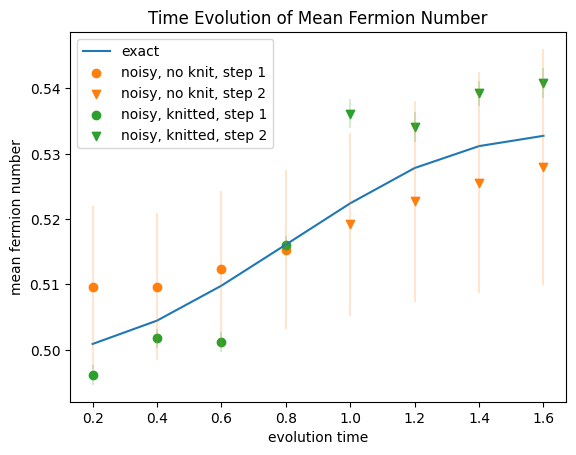

In [34]:
color_0, color_1, color_2 = 'tab:blue', 'tab:orange', 'tab:green'
a = len(ferm_num_trotter_evol_noisy_no_knit_seed1763593036)#, len(ferm_num_trotter_evol_noisy_no_knit_seed1763585734), 8#len(ferm_num_trotter_evol_noisy_knit)

plt.plot(trotter_steps[:a], ferm_num_exact_no_noise_no_knit[:a], label='exact', color=color_0)


plt.scatter(trotter_steps[:a//2], averages[:a//2],\
            label='noisy, no knit, step 1', color=color_1)
plt.errorbar(trotter_steps[:a//2], averages[:a//2], errors[:a//2],\
             alpha=0.2, ls='none', color=color_1)
plt.scatter(trotter_steps[a//2:a], averages[a//2:],\
            label='noisy, no knit, step 2', color=color_1, marker='v')
plt.errorbar(trotter_steps[a//2:a], averages[a//2:], errors[a//2:],\
             alpha=0.2, ls='none', color=color_1)

plt.scatter(trotter_steps[:4], ferm_num_trotter_evol_noisy_knit[:4],\
            label='noisy, knitted, step 1', color=color_2)
plt.errorbar(trotter_steps[:4], ferm_num_trotter_evol_noisy_knit[:4],\
             bs_error_trotter_evol_noisy_knit[:4], alpha=0.2, ls='none', color=color_2)
plt.scatter(trotter_steps[4:8], ferm_num_trotter_evol_noisy_knit[4:8],\
            label='noisy, knitted, step 2', color=color_2, marker='v')
plt.errorbar(trotter_steps[4:8], ferm_num_trotter_evol_noisy_knit[4:],\
             bs_error_trotter_evol_noisy_knit[4:], alpha=0.2, ls='none', color=color_2)

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('Time Evolution of Mean Fermion Number')
plt.legend()
plt.savefig('figures/trotter_convergence.pdf')
plt.show()
del(a, color_0, color_1, color_2)

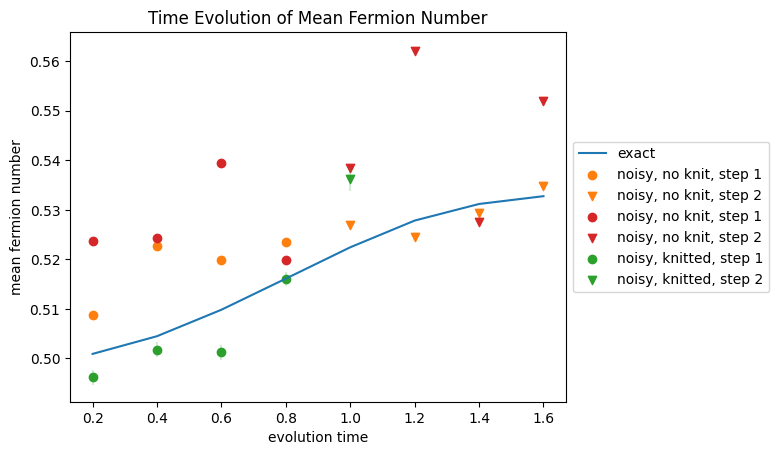

In [35]:
# a, b, c = len(ferm_num_trotter_evol_noisy_knit), len(ferm_num_trotter_evol_noisy_no_knit),\
#              len(ferm_num_trotter_evol_noisy_no_knit_take2)
a, b, c = 8, len(ferm_num_trotter_evol_noisy_no_knit),\
             len(ferm_num_trotter_evol_noisy_no_knit_take2)

plt.plot(trotter_steps[:b], ferm_num_exact_no_noise_no_knit[:b], label='exact')

plt.scatter(trotter_steps[:b//2], ferm_num_trotter_evol_noisy_no_knit[:b//2],\
            label='noisy, no knit, step 1', color='tab:orange')
plt.errorbar(trotter_steps[:b//2], ferm_num_trotter_evol_noisy_no_knit[:b//2], bs_error_trotter_evol_noisy_no_knit[:b//2],\
             alpha=0.2, ls='none', color='tab:orange')
plt.scatter(trotter_steps[b//2:b], ferm_num_trotter_evol_noisy_no_knit[b//2:],\
            label='noisy, no knit, step 2', color='tab:orange', marker='v')
plt.errorbar(trotter_steps[b//2:b], ferm_num_trotter_evol_noisy_no_knit[b//2:], bs_error_trotter_evol_noisy_no_knit[b//2:],\
             alpha=0.2, ls='none', color='tab:orange')

plt.scatter(trotter_steps[:c//2], ferm_num_trotter_evol_noisy_no_knit_take2[:c//2],\
            label='noisy, no knit, step 1', color='tab:red')
plt.errorbar(trotter_steps[:c//2], ferm_num_trotter_evol_noisy_no_knit_take2[:c//2], bs_error_trotter_evol_noisy_no_knit_take2[:c//2],\
             alpha=0.2, ls='none', color='tab:red')
plt.scatter(trotter_steps[c//2:c], ferm_num_trotter_evol_noisy_no_knit_take2[c//2:],\
            label='noisy, no knit, step 2', color='tab:red', marker='v')
plt.errorbar(trotter_steps[c//2:c], ferm_num_trotter_evol_noisy_no_knit_take2[c//2:], bs_error_trotter_evol_noisy_no_knit_take2[c//2:],\
             alpha=0.2, ls='none', color='tab:red')

plt.scatter(trotter_steps[:4], ferm_num_trotter_evol_noisy_knit[:4],\
            label='noisy, knitted, step 1', color='tab:green')
plt.errorbar(trotter_steps[:4], ferm_num_trotter_evol_noisy_knit[:4],\
             bs_error_trotter_evol_noisy_knit[:4], alpha=0.2, ls='none', color='tab:green')
plt.scatter(trotter_steps[4:5], ferm_num_trotter_evol_noisy_knit[4:5],\
            label='noisy, knitted, step 2', color='tab:green', marker='v')
plt.errorbar(trotter_steps[4:5], ferm_num_trotter_evol_noisy_knit[4:5],\
             bs_error_trotter_evol_noisy_knit[4:5], alpha=0.2, ls='none', color='tab:green')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('Time Evolution of Mean Fermion Number')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('figures/trotter_convergence.pdf', bbox_inches='tight')
plt.show()
del(a, b, c)

In [36]:
ferm_num_trotter_evol_noisy_knit_step1 = []
with open('data/ferm_num_trotter_evol_noisy_knit_step1.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        ferm_num_trotter_evol_noisy_knit_step1.append(float(val))

bs_error_trotter_evol_noisy_knit_step1 = []
with open('data/bs_error_trotter_evol_noisy_knit_step1.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        bs_error_trotter_evol_noisy_knit_step1.append(float(val))

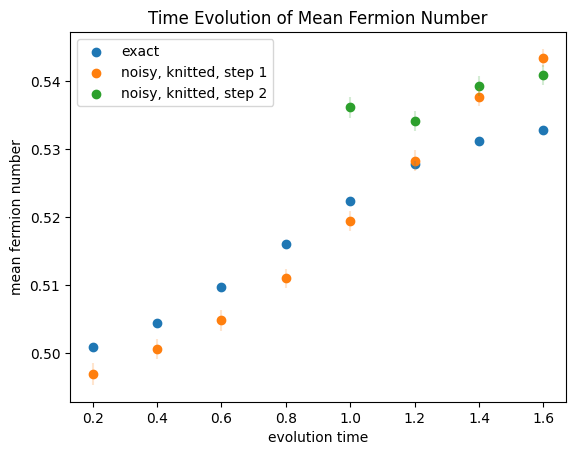

In [37]:
a = len(ferm_num_trotter_evol_noisy_knit)
b = len(ferm_num_trotter_evol_noisy_knit)
c = len(ferm_num_trotter_evol_noisy_knit_step1)
plt.scatter(trotter_steps[:a], ferm_num_exact_no_noise_no_knit[:a], label='exact')
plt.errorbar(trotter_steps[:a], ferm_num_exact_no_noise_no_knit[:a], bs_error_exact_no_noise_no_knit[:a], alpha=0.2, ls='none')
plt.scatter(trotter_steps[:c], ferm_num_trotter_evol_noisy_knit_step1, label='noisy, knitted, step 1')
plt.errorbar(trotter_steps[:c], ferm_num_trotter_evol_noisy_knit_step1, bs_error_trotter_evol_noisy_knit_step1, alpha=0.2, ls='none')
plt.scatter(trotter_steps[4:8], ferm_num_trotter_evol_noisy_knit[4:], label='noisy, knitted, step 2')
plt.errorbar(trotter_steps[4:8], ferm_num_trotter_evol_noisy_knit[4:], bs_error_trotter_evol_noisy_knit[:4], alpha=0.2, ls='none')
plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('Time Evolution of Mean Fermion Number')
plt.legend()
#plt.savefig('figures/trotter_convergence.pdf')
plt.show()
del(a)

In [25]:
ferm_num_trotter_evol_no_noise_no_knit = []
with open('data/ferm_num_trotter_evol_no_noise_no_knit.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        ferm_num_trotter_evol_no_noise_no_knit.append(float(val))

bs_error_trotter_evol_no_noise_no_knit = []
with open('data/bs_error_trotter_evol_no_noise_no_knit.txt', 'r') as file:
    for line in file:
        val = line[:-1]
        bs_error_trotter_evol_no_noise_no_knit.append(float(val))

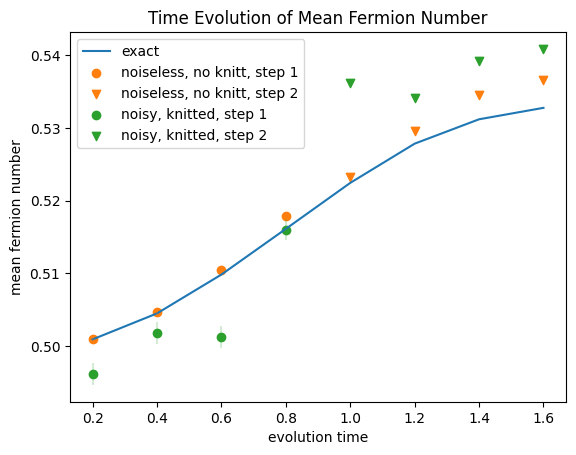

In [26]:
a = len(ferm_num_trotter_evol_noisy_knit)
b = len(ferm_num_trotter_evol_no_noise_no_knit)
plt.plot(trotter_steps[:b], ferm_num_exact_no_noise_no_knit[:b], label='exact')
#plt.errorbar(trotter_steps[:a], ferm_num_exact_no_noise_no_knit[:a], bs_error_exact_no_noise_no_knit[:a], alpha=0.2, ls='none')

plt.scatter(trotter_steps[:b//2], ferm_num_trotter_evol_no_noise_no_knit[:b//2],\
            label='noiseless, no knitt, step 1', color='tab:orange')
plt.errorbar(trotter_steps[:b//2], ferm_num_trotter_evol_no_noise_no_knit[:b//2], bs_error_trotter_evol_no_noise_no_knit[:b//2],\
             alpha=0.2, ls='none', color='tab:orange')
plt.scatter(trotter_steps[b//2:b], ferm_num_trotter_evol_no_noise_no_knit[b//2:],\
            label='noiseless, no knitt, step 2', color='tab:orange', marker='v')
plt.errorbar(trotter_steps[b//2:b], ferm_num_trotter_evol_no_noise_no_knit[b//2:], bs_error_trotter_evol_no_noise_no_knit[b//2:],\
             alpha=0.2, ls='none', color='tab:orange')

plt.scatter(trotter_steps[:4], ferm_num_trotter_evol_noisy_knit[:4],\
            label='noisy, knitted, step 1', color='tab:green')
plt.errorbar(trotter_steps[:4], ferm_num_trotter_evol_noisy_knit[:4],\
             bs_error_trotter_evol_noisy_knit[:4], alpha=0.2, ls='none', color='tab:green')
plt.scatter(trotter_steps[4:8], ferm_num_trotter_evol_noisy_knit[4:],\
            label='noisy, knitted, step 2', color='tab:green', marker='v')
# plt.errorbar(trotter_steps[4:6], ferm_num_trotter_evol_noisy_knit[4:6],\
#              bs_error_trotter_evol_noisy_knit[4:6], alpha=0.2, ls='none', color='tab:green')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('Time Evolution of Mean Fermion Number')
plt.legend()
plt.savefig('figures/trotter_convergence.pdf')
plt.show()
del(a, b)

In [27]:
import pickle
import import_ipynb
from functions import *

In [28]:
ferm_num_trotter_evol_noisy_knit_seed1764002119 = []
bs_error_trotter_evol_noisy_knit_seed1764002119 = []
for i in range(4):
    step = 1
    shots = 16384
    eps = 0.2*(i+1)
    with open('data/noisy_knitted_trotter_evol/step'\
              +str(step)+'_epsilon'+str(eps)[0]+str(eps)[2]+'_count'+str(shots)+'_with_noise_knitted_seed1764002119.pkl', 'rb') as file:
        counts = pickle.load(file)
    ferm_num_trotter_evol_noisy_knit_seed1764002119.append(fermion_number(counts, mid))
    bs_error_trotter_evol_noisy_knit_seed1764002119.append(bootstrap_error(counts, mid, shots))

for i in range(4):
    step = 2
    shots = 16384
    eps = 0.1*(i+5)
    with open('data/noisy_knitted_trotter_evol/step'\
              +str(step)+'_epsilon'+str(eps)[0]+str(eps)[2]+'_count'+str(shots)+'_with_noise_knitted_seed1764002119.pkl', 'rb') as file:
        counts = pickle.load(file)
    ferm_num_trotter_evol_noisy_knit_seed1764002119.append(fermion_number(counts, mid))
    bs_error_trotter_evol_noisy_knit_seed1764002119.append(bootstrap_error(counts, mid, shots))

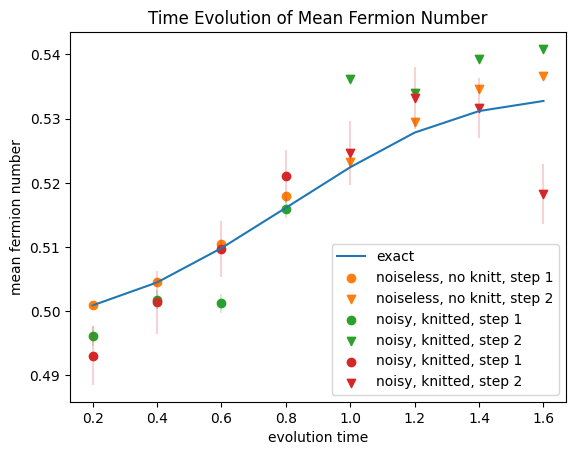

In [29]:
a = len(ferm_num_trotter_evol_noisy_knit)
b = len(ferm_num_trotter_evol_no_noise_no_knit)
c = len(ferm_num_trotter_evol_noisy_knit_seed1764002119)
plt.plot(trotter_steps[:b], ferm_num_exact_no_noise_no_knit[:b], label='exact')
#plt.errorbar(trotter_steps[:a], ferm_num_exact_no_noise_no_knit[:a], bs_error_exact_no_noise_no_knit[:a], alpha=0.2, ls='none')

plt.scatter(trotter_steps[:b//2], ferm_num_trotter_evol_no_noise_no_knit[:b//2],\
            label='noiseless, no knitt, step 1', color='tab:orange')
plt.errorbar(trotter_steps[:b//2], ferm_num_trotter_evol_no_noise_no_knit[:b//2], bs_error_trotter_evol_no_noise_no_knit[:b//2],\
             alpha=0.2, ls='none', color='tab:orange')
plt.scatter(trotter_steps[b//2:b], ferm_num_trotter_evol_no_noise_no_knit[b//2:],\
            label='noiseless, no knitt, step 2', color='tab:orange', marker='v')
plt.errorbar(trotter_steps[b//2:b], ferm_num_trotter_evol_no_noise_no_knit[b//2:], bs_error_trotter_evol_no_noise_no_knit[b//2:],\
             alpha=0.2, ls='none', color='tab:orange')

plt.scatter(trotter_steps[:4], ferm_num_trotter_evol_noisy_knit[:4],\
            label='noisy, knitted, step 1', color='tab:green')
plt.errorbar(trotter_steps[:4], ferm_num_trotter_evol_noisy_knit[:4],\
             bs_error_trotter_evol_noisy_knit[:4], alpha=0.2, ls='none', color='tab:green')
plt.scatter(trotter_steps[4:8], ferm_num_trotter_evol_noisy_knit[4:],\
            label='noisy, knitted, step 2', color='tab:green', marker='v')
# plt.errorbar(trotter_steps[4:6], ferm_num_trotter_evol_noisy_knit[4:6],\
#              bs_error_trotter_evol_noisy_knit[4:6], alpha=0.2, ls='none', color='tab:green')

plt.scatter(trotter_steps[:max(c//2, 4)], ferm_num_trotter_evol_noisy_knit_seed1764002119[:max(c//2, 4)],\
            label='noisy, knitted, step 1', color='tab:red')
plt.errorbar(trotter_steps[:max(c//2, 4)], ferm_num_trotter_evol_noisy_knit_seed1764002119[:max(c//2, 4)],\
             bs_error_trotter_evol_noisy_knit_seed1764002119[:max(c//2, 4)], alpha=0.2, ls='none', color='tab:red')
plt.scatter(trotter_steps[max(c//2, 4):c], ferm_num_trotter_evol_noisy_knit_seed1764002119[max(c//2, 4):c],\
            label='noisy, knitted, step 2', color='tab:red', marker='v')
plt.errorbar(trotter_steps[max(c//2, 4):c], ferm_num_trotter_evol_noisy_knit_seed1764002119[max(c//2, 4):c],\
             bs_error_trotter_evol_noisy_knit_seed1764002119[max(c//2, 4):c], alpha=0.2, ls='none', color='tab:red')

plt.xlabel('evolution time')
plt.ylabel('mean fermion number')
plt.title('Time Evolution of Mean Fermion Number')
plt.legend(loc='lower right')
plt.savefig('figures/trotter_convergence.pdf')
plt.show()
del(a, b, c)

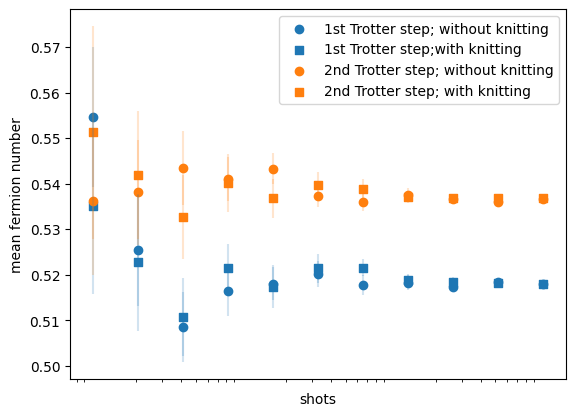

In [81]:
plt.scatter(shots_list, ferm_num_step1_epsilon08_no_noise_no_knit, label='1st Trotter step; without knitting')
plt.errorbar(shots_list, ferm_num_step1_epsilon08_no_noise_no_knit, bs_error_step1_epsilon08_no_noise_no_knit, alpha=0.2, ls='none')
plt.scatter(shots_list, ferm_num_step1_epsilon08_no_noise_knitted, label='1st Trotter step;with knitting',\
            color='tab:blue', marker='s')
plt.errorbar(shots_list, ferm_num_step1_epsilon08_no_noise_knitted, bs_error_step1_epsilon08_no_noise_knitted, alpha=0.2, ls='none',\
             color='tab:blue')
plt.scatter(shots_list, ferm_num_step2_epsilon08_no_noise_no_knit, label='2nd Trotter step; without knitting',\
            color='tab:orange')
plt.errorbar(shots_list, ferm_num_step2_epsilon08_no_noise_no_knit, bs_error_step2_epsilon08_no_noise_no_knit, alpha=0.2, ls='none',\
             color='tab:orange')
plt.scatter(shots_list, ferm_num_step2_epsilon08_no_noise_knitted, label='2nd Trotter step; with knitting',\
            color='tab:orange', marker='s')
plt.errorbar(shots_list, ferm_num_step2_epsilon08_no_noise_knitted, bs_error_step2_epsilon08_no_noise_knitted, alpha=0.2, ls='none',\
             color='tab:orange')
plt.xscale('log')
plt.xlabel('shots')
plt.ylabel('mean fermion number')
plt.xticks([])
plt.legend()
plt.savefig('figures/noiseless_convergence.pdf')
plt.show()

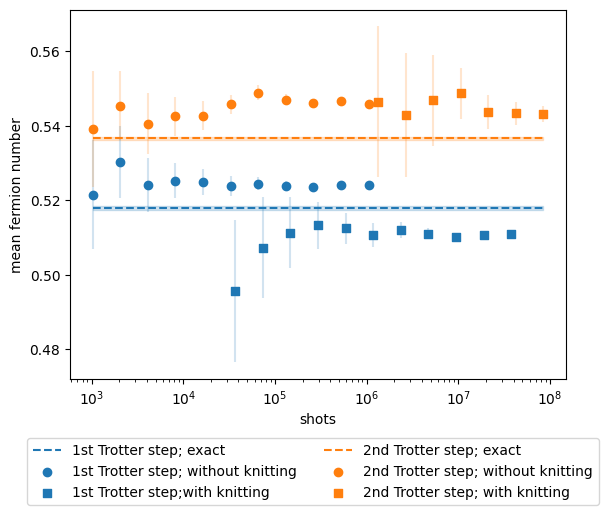

In [95]:
# plt.scatter(shots_list, ferm_num_step1_epsilon08_no_noise_no_knit, label='1st Trotter step; without knitting')
# plt.errorbar(shots_list, ferm_num_step1_epsilon08_no_noise_no_knit, bs_error_step1_epsilon08_no_noise_no_knit, alpha=0.2, ls='none')
# plt.scatter(shots_list, ferm_num_step1_epsilon08_no_noise_knitted, label='1st Trotter step;with knitting',\
#             color='tab:blue', marker='s')
# plt.errorbar(shots_list, ferm_num_step1_epsilon08_no_noise_knitted, bs_error_step1_epsilon08_no_noise_knitted, alpha=0.2, ls='none',\
#              color='tab:blue')
# plt.scatter(shots_list, ferm_num_step2_epsilon08_no_noise_no_knit, label='2nd Trotter step; without knitting',\
#             color='tab:orange')
# plt.errorbar(shots_list, ferm_num_step2_epsilon08_no_noise_no_knit, bs_error_step2_epsilon08_no_noise_no_knit, alpha=0.2, ls='none',\
#              color='tab:orange')
# plt.scatter(shots_list, ferm_num_step2_epsilon08_no_noise_knitted, label='2nd Trotter step; with knitting',\
#             color='tab:orange', marker='s')
# plt.errorbar(shots_list, ferm_num_step2_epsilon08_no_noise_knitted, bs_error_step2_epsilon08_no_noise_knitted, alpha=0.2, ls='none',\
#              color='tab:orange')
full_span = [1024, (6**4)*(1024*64)]

plt.plot(full_span, [ferm_num_step1_epsilon08_no_noise_no_knit[-1] for _ in range(2)], color='tab:blue', linestyle='dashed',\
         label='1st Trotter step; exact')
plt.fill_between(full_span,\
                 [ferm_num_step1_epsilon08_no_noise_no_knit[-1]+bs_error_step1_epsilon08_no_noise_no_knit[-1] for _ in range(2)],\
                 [ferm_num_step1_epsilon08_no_noise_no_knit[-1]-bs_error_step1_epsilon08_no_noise_no_knit[-1] for _ in range(2)],\
                  alpha=0.2, color = 'tab:blue')
plt.scatter(shots_list, ferm_num_step1_epsilon08_with_noise_no_knit, label='1st Trotter step; without knitting')
plt.errorbar(shots_list, ferm_num_step1_epsilon08_with_noise_no_knit, bs_error_step1_epsilon08_with_noise_no_knit, alpha=0.2, ls='none')
plt.scatter(shots_list_36, ferm_num_step1_epsilon08_with_noise_knitted, label='1st Trotter step;with knitting',\
            color='tab:blue', marker='s')
plt.errorbar(shots_list_36, ferm_num_step1_epsilon08_with_noise_knitted, bs_error_step1_epsilon08_with_noise_knitted, alpha=0.2, ls='none',\
             color='tab:blue')

plt.plot(full_span, [ferm_num_step2_epsilon08_no_noise_no_knit[-1] for _ in range(2)], color='tab:orange', linestyle='dashed',\
         label='2nd Trotter step; exact')
plt.fill_between(full_span,\
                 [ferm_num_step2_epsilon08_no_noise_no_knit[-1]+bs_error_step2_epsilon08_no_noise_no_knit[-1] for i in range(2)],\
                 [ferm_num_step2_epsilon08_no_noise_no_knit[-1]-bs_error_step2_epsilon08_no_noise_no_knit[-1] for i in range(2)],\
                  alpha=0.2, color = 'tab:orange')
plt.scatter(shots_list, ferm_num_step2_epsilon08_with_noise_no_knit, label='2nd Trotter step; without knitting',\
            color='tab:orange')
plt.errorbar(shots_list, ferm_num_step2_epsilon08_with_noise_no_knit, bs_error_step2_epsilon08_with_noise_no_knit, alpha=0.2, ls='none',\
             color='tab:orange')
a=len(ferm_num_step2_epsilon08_with_noise_knitted)
plt.scatter(shots_list_6_t_4[:a], ferm_num_step2_epsilon08_with_noise_knitted, label='2nd Trotter step; with knitting',\
            color='tab:orange', marker='s')
plt.errorbar(shots_list_6_t_4[:a], ferm_num_step2_epsilon08_with_noise_knitted, bs_error_step2_epsilon08_with_noise_knitted, alpha=0.2, ls='none',\
             color='tab:orange')
del(a)

plt.legend(loc='center left', bbox_to_anchor=(-0.1, -0.25), ncol=2)

plt.xscale('log')
plt.xlabel('shots')
plt.ylabel('mean fermion number')
plt.savefig('figures/noisy_convergence.pdf', bbox_inches='tight')
plt.show()

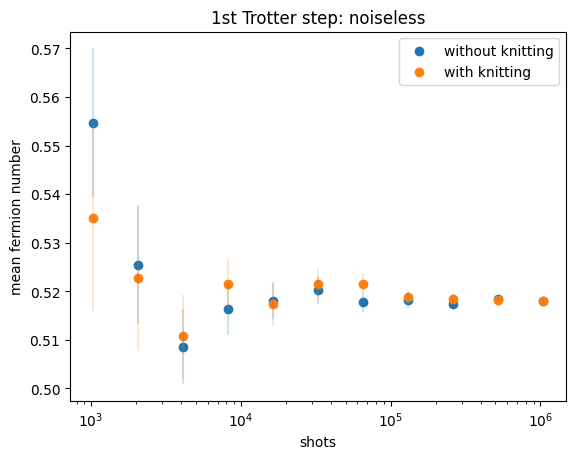

In [27]:
plt.scatter(shots_list, ferm_num_step1_epsilon08_no_noise_no_knit, label='without knitting')
plt.errorbar(shots_list, ferm_num_step1_epsilon08_no_noise_no_knit, bs_error_step1_epsilon08_no_noise_no_knit, alpha=0.2, ls='none')
plt.scatter(shots_list, ferm_num_step1_epsilon08_no_noise_knitted, label='with knitting')
plt.errorbar(shots_list, ferm_num_step1_epsilon08_no_noise_knitted, bs_error_step1_epsilon08_no_noise_knitted, alpha=0.2, ls='none')
plt.xscale('log')
plt.xlabel('shots')
plt.ylabel('mean fermion number')
plt.title('1st Trotter step: noiseless')
plt.legend()
plt.show()

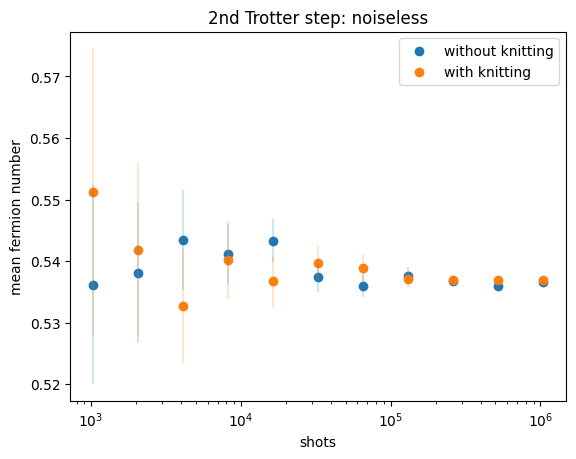

In [34]:
plt.scatter(shots_list, ferm_num_step2_epsilon08_no_noise_no_knit, label='without knitting')
plt.errorbar(shots_list, ferm_num_step2_epsilon08_no_noise_no_knit, bs_error_step2_epsilon08_no_noise_no_knit, alpha=0.2, ls='none')
plt.scatter(shots_list, ferm_num_step2_epsilon08_no_noise_knitted, label='with knitting')
plt.errorbar(shots_list, ferm_num_step2_epsilon08_no_noise_knitted, bs_error_step2_epsilon08_no_noise_knitted, alpha=0.2, ls='none')
plt.xscale('log')
plt.xlabel('shots')
plt.ylabel('mean fermion number')
plt.title('2nd Trotter step: noiseless')
plt.legend()
plt.show()

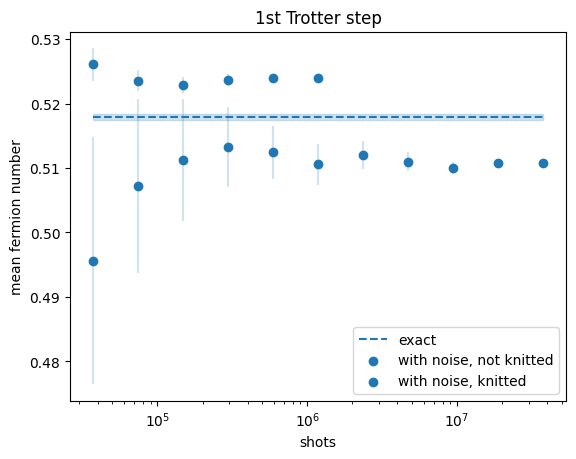

In [47]:
plt.plot(shots_list_36, [ferm_num_step1_epsilon08_no_noise_no_knit[-1] for _ in range(len(shots_list))], color='tab:blue', linestyle='dashed',\
         label='exact')
plt.fill_between(shots_list_36,\
                 [ferm_num_step1_epsilon08_no_noise_no_knit[-1]+bs_error_step1_epsilon08_no_noise_no_knit[-1] for i in range(len(shots_list))],\
                 [ferm_num_step1_epsilon08_no_noise_no_knit[-1]-bs_error_step1_epsilon08_no_noise_no_knit[-1] for i in range(len(shots_list))],\
                  alpha=0.2, color = 'tab:blue')
plt.scatter(shots_list_36[:6], ferm_num_step1_epsilon08_with_noise_no_knit, label='with noise, not knitted', color = 'tab:blue')
plt.errorbar(shots_list_36[:6], ferm_num_step1_epsilon08_with_noise_no_knit, bs_error_step1_epsilon08_with_noise_no_knit, alpha=0.2,\
             ls='none', color='tab:blue')
plt.scatter(shots_list_36, ferm_num_step1_epsilon08_with_noise_knitted, color='tab:blue', label='with noise, knitted')
plt.errorbar(shots_list_36, ferm_num_step1_epsilon08_with_noise_knitted, bs_error_step1_epsilon08_with_noise_knitted, alpha=0.2,\
             ls='none', color='tab:blue')
plt.xscale('log')
plt.xlabel('shots')
plt.ylabel('mean fermion number')
plt.title('1st Trotter step')
plt.legend(loc='lower right')
plt.show()

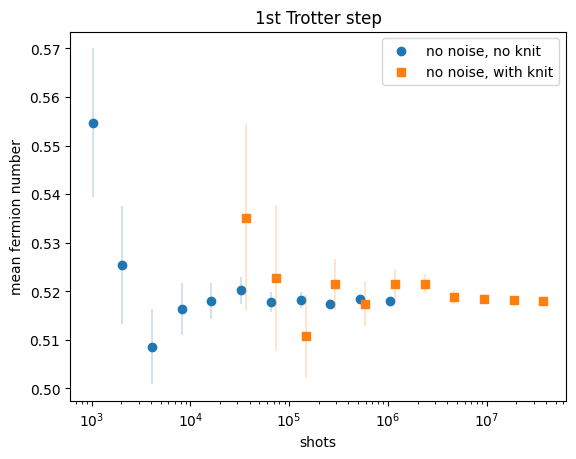

In [27]:
plt.scatter(shots_list, ferm_num_step1_epsilon08_no_noise_no_knit, label = 'no noise, no knit')
plt.errorbar(shots_list, ferm_num_step1_epsilon08_no_noise_no_knit, bs_error_step1_epsilon08_no_noise_no_knit, alpha=0.2, ls='none')
plt.scatter([i*36 for i in shots_list], ferm_num_step1_epsilon08_no_noise_knitted, marker = 's', label = 'no noise, with knit')
plt.errorbar([i*36 for i in shots_list], ferm_num_step1_epsilon08_no_noise_knitted, bs_error_step1_epsilon08_no_noise_knitted, alpha=0.2, ls='none')
# plt.scatter(shots_list, ferm_num_step1_epsilon08_with_noise_no_knit, marker = 'v', label = 'with noise, no knit')
# plt.errorbar(shots_list, ferm_num_step1_epsilon08_with_noise_no_knit, bs_error_step1_epsilon08_with_noise_no_knit, alpha=0.2, ls='none')
# plt.scatter(shots_list, ferm_num_step1_epsilon08_with_noise_knitted, marker = '*', label = 'with noise, with knit')
# plt.errorbar(shots_list, ferm_num_step1_epsilon08_with_noise_knitted, bs_error_step1_epsilon08_with_noise_knitted, alpha=0.2, ls='none')
plt.xscale('log')
plt.xlabel('shots')
plt.ylabel('mean fermion number')
plt.title('1st Trotter step')
plt.legend()
plt.show()

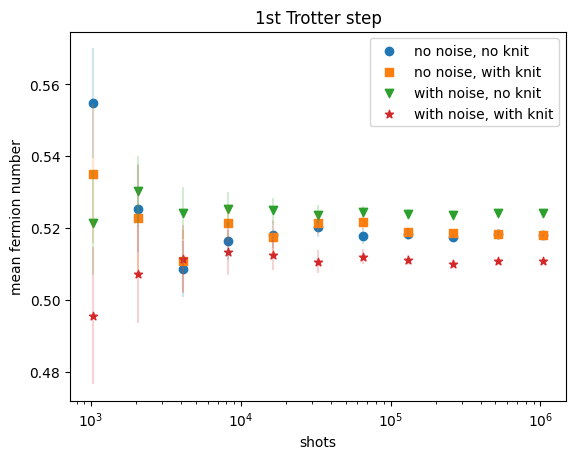

In [23]:
plt.scatter(shots_list, ferm_num_step1_epsilon08_no_noise_no_knit, label = 'no noise, no knit')
plt.errorbar(shots_list, ferm_num_step1_epsilon08_no_noise_no_knit, bs_error_step1_epsilon08_no_noise_no_knit, alpha=0.2, ls='none')
plt.scatter(shots_list, ferm_num_step1_epsilon08_no_noise_knitted, marker = 's', label = 'no noise, with knit')
plt.errorbar(shots_list, ferm_num_step1_epsilon08_no_noise_knitted, bs_error_step1_epsilon08_no_noise_knitted, alpha=0.2, ls='none')
plt.scatter(shots_list, ferm_num_step1_epsilon08_with_noise_no_knit, marker = 'v', label = 'with noise, no knit')
plt.errorbar(shots_list, ferm_num_step1_epsilon08_with_noise_no_knit, bs_error_step1_epsilon08_with_noise_no_knit, alpha=0.2, ls='none')
plt.scatter(shots_list, ferm_num_step1_epsilon08_with_noise_knitted, marker = '*', label = 'with noise, with knit')
plt.errorbar(shots_list, ferm_num_step1_epsilon08_with_noise_knitted, bs_error_step1_epsilon08_with_noise_knitted, alpha=0.2, ls='none')
plt.xscale('log')
plt.xlabel('shots')
plt.ylabel('mean fermion number')
plt.title('1st Trotter step')
plt.legend()
plt.show()

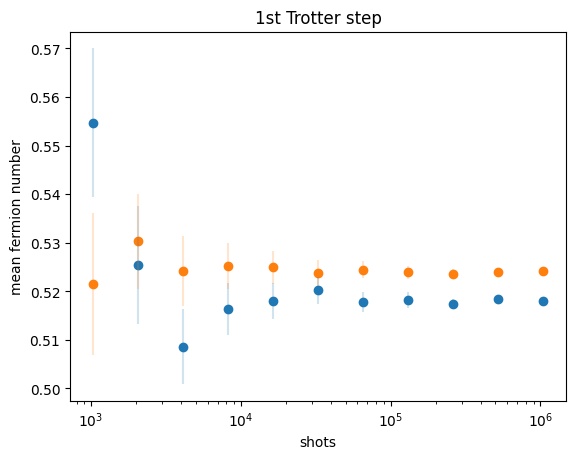

In [12]:
plt.scatter(shots_list, ferm_num_step1_epsilon08_no_noise_no_knit)
plt.errorbar(shots_list, ferm_num_step1_epsilon08_no_noise_no_knit, bs_error_step1_epsilon08_no_noise_no_knit, alpha=0.2, ls='none')
plt.scatter(shots_list, ferm_num_step1_epsilon08_with_noise_no_knit)
plt.errorbar(shots_list, ferm_num_step1_epsilon08_with_noise_no_knit, bs_error_step1_epsilon08_with_noise_no_knit, alpha=0.2, ls='none')
# plt.scatter(shots_list, ferm_num_step1_epsilon08_no_noise_knitted)
# plt.errorbar(shots_list, ferm_num_step1_epsilon08_no_noise_knitted, bs_error_step1_epsilon08_no_noise_knitted, alpha=0.2, ls='none')
# plt.scatter(shots_list, ferm_num_step1_epsilon08_with_noise_knitted)
# plt.errorbar(shots_list, ferm_num_step1_epsilon08_with_noise_knitted, bs_error_step1_epsilon08_with_noise_knitted, alpha=0.2, ls='none')
plt.xscale('log')
plt.xlabel('shots')
plt.ylabel('mean fermion number')
plt.title('1st Trotter step')
plt.show()